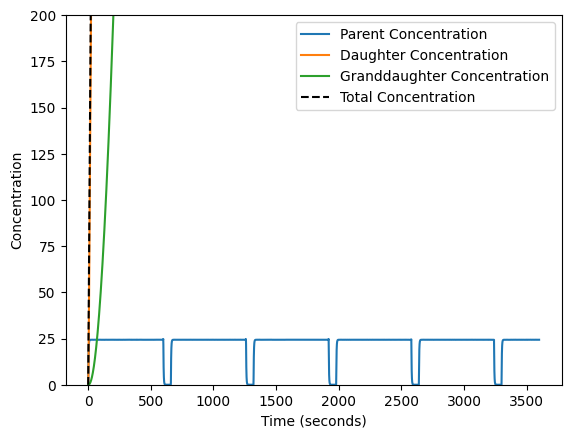

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Half-lives (in seconds)
T_half_P = 1.687
T_half_D = 10.51 * 60
T_half_G = 91.8 * 60

# Decay constants
lambda_P = np.log(2) / T_half_P
lambda_D = np.log(2) / T_half_D
lambda_G = np.log(2) / T_half_G

# Time points
t = np.linspace(0, 3600, 3600)  # Simulate for 1 hour

# Initial number of nuclei
N_P0 = 0
N_D0 = 0
N_G0 = 0

# Placeholder function for the unknown addition rate
def Q(t):
    return 10 if (t % 660 < 600) else 0  # Add parent nuclei every 20 seconds for 10 seconds

# Define the system of differential equations
def decay_chain(t, y):
    N_P, N_D, N_G = y
    dN_P_dt = -lambda_P * N_P + Q(t)
    dN_D_dt = lambda_P * N_P - lambda_D * N_D
    dN_G_dt = lambda_D * N_D - lambda_G * N_G
    return [dN_P_dt, dN_D_dt, dN_G_dt]

# Solve the system of equations
sol = solve_ivp(decay_chain, [0, t[-1]], [N_P0, N_D0, N_G0], t_eval=t)

# Extract solutions
N_P = sol.y[0]
N_D = sol.y[1]
N_G = sol.y[2]

# Calculate total concentration
N_total = N_P + N_D + N_G

# Plot the results
plt.plot(t, N_P, label='Parent Concentration')
plt.plot(t, N_D, label='Daughter Concentration')
plt.plot(t, N_G, label='Granddaughter Concentration')
plt.plot(t, N_total, label='Total Concentration', linestyle='--', color='black')
plt.xlabel('Time (seconds)')
plt.ylabel('Concentration')
plt.legend()
plt.ylim(0, 200)  # Set y-axis range up to 200
plt.show()
